In [87]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, morphology, measure, color
from skimage.data import binary_blobs
from skimage.util import img_as_ubyte
from scipy.ndimage import label
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from scipy.ndimage import convolve

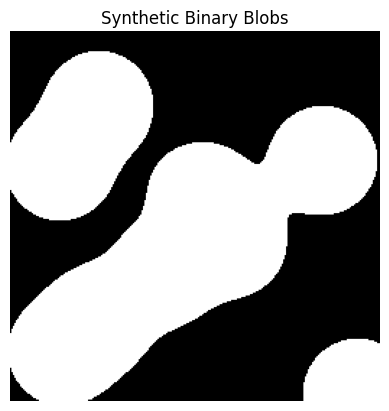

In [88]:
image = binary_blobs(length=256, blob_size_fraction=0.3, volume_fraction=0.5) # control size and distribution

plt.imshow(image, cmap='gray')
plt.title("Synthetic Binary Blobs")
plt.axis('off')
plt.show()

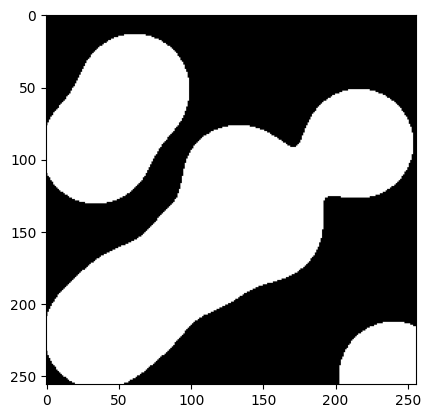

In [89]:
thresh = threshold_otsu(image)
binary = image > thresh
plt.imshow(binary, cmap='gray')


In [90]:
labeled_array, num_components = label(binary)

In [91]:
region = measure.regionprops(measure.label(binary))[0]
euler_number = region.euler_number

In [92]:
skeleton = morphology.skeletonize(binary)

In [93]:
def count_vertices_edges(skel):
    kernel = np.array([[1,1,1],
                       [1,10,1],
                       [1,1,1]])

    neighbor_count = convolve(skel.astype(np.uint8), kernel, mode='constant', cval=0)


    junctions = np.logical_and(skel, neighbor_count >= 13)
    ends = np.logical_and(skel, neighbor_count == 11)

    num_vertices = np.sum(junctions)
    num_endpoints = np.sum(ends)
    num_edges = np.sum(skel) - num_vertices
    return num_vertices + num_endpoints, num_edges

In [94]:

num_vertices, num_edges = count_vertices_edges(skeleton)

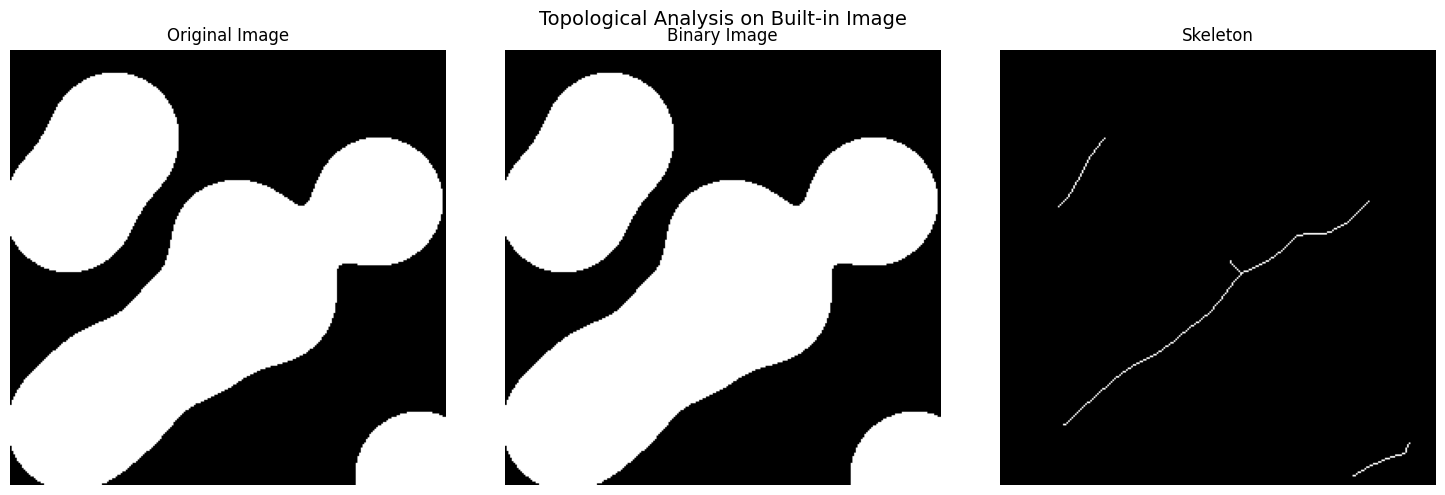

Topological Descriptors:
Number of Connected Components (C): 3
Euler Number (C - H): 1
Estimated Vertices (Junctions + Endpoints): 10
Estimated Edges (Skeleton Pixels - Vertices): 267


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary Image')
axes[2].imshow(skeleton, cmap='gray')
axes[2].set_title('Skeleton')

for ax in axes:
    ax.axis('off')

plt.suptitle("Topological Analysis on Built-in Image", fontsize=14)
plt.tight_layout()
plt.show()

# Print descriptors
print("Topological Descriptors:")
print(f"Number of Connected Components (C): {num_components}")
print(f"Euler Number (C - H): {euler_number}")
print(f"Estimated Vertices (Junctions + Endpoints): {num_vertices}")
print(f"Estimated Edges (Skeleton Pixels - Vertices): {num_edges}")